In [1]:
import numpy as np
from IPython.display import display, Image
import matplotlib.pyplot as plt
from numpy.linalg import solve
import warnings
warnings.filterwarnings('ignore')

### Exercise 5: Wien's displacement constant.

Planck's radiation law tells us that the radiation intensity per unit area and per
unit wavelength λ for a black body at temperature T is:

$$I(\lambda)=\frac{2\pi\,h\,c^2\,\lambda^{-5}}{\text{e}^{hc/\lambda k_B\,T}-1},$$

where h is Planck's constant, c is the speed of light, and $k_B$ is Boltzmann's constant.

1. Show that the wavelength of maximum emitted radiation is a solution of the equation

    $$5\text{e}^{-hc/\lambda k_B\,T}+\frac{h c}{\lambda k_B T}-5=0.$$

    Making the change of variable $x=hc/\lambda\,k_B\,T$, the equation can be rewritten as

    $$5\text{e}^{-x}+x-5=0,$$

    and the wavelength of maximum radiation satisfies Wien's displacement law:

    $$\lambda =\frac{b}{T},$$

    where $b$ is Wien's displacement constant and $x$ is the solution of the nonlinear equation above.

$$b = \frac{hc}{k_B x}$$
   
---

2. Write a program to obtain the value of $x$ with a precision better than $10^{-6}$ using the bisection method.      
   Calculate the value of Wien's displacement constant.

---


Bisection method's iterations: 21
Wien's Constant = 0.002898 m·K


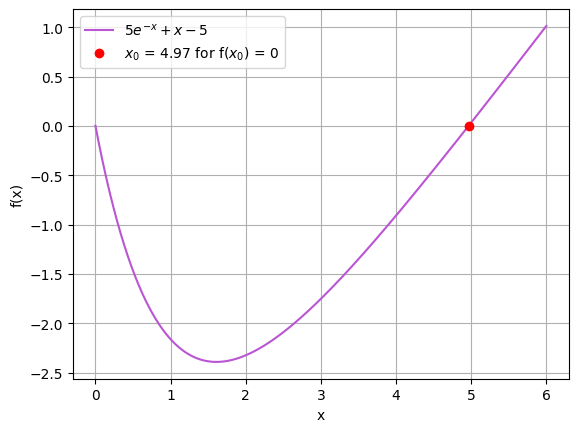

In [2]:
def f(x):
    return 5*np.exp(-x) + x - 5

def bisection(f, a, b, eps):
    fa = f(a)
    fb = f(b)

    it = 0
    while b - a > eps:
        m = a + (b - a) / 2.0
        fm = f(m)
        it += 1

        if np.sign(fa) == np.sign(fm):
            a = m
            fa = fm
        else:
            b = m
            fb = fm
    print("Bisection method's iterations:", it)
    return m

x0 = bisection(f, 4, 6, 1e-6)
h = 6.62607e-34
c = 2.99792e8
kb = 1.38064e-23
b = h*c/(kb*x0)
print(f"Wien's Constant = {round(b, 6)} m·K")
x = np.linspace(0, 6, 1000)
plt.plot(x, f(x), color = 'mediumorchid', label = "$5e^{-x} + x - 5$")
plt.plot(x0, 0, 'ro', label = f"$x_0$ = {round(x0, 2)} for f($x_0$) = 0")
plt.grid()
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

3. Wien's displacement law is the basis of pyrometry, which allows measuring the temperature of objects by observing the thermal radiation they emit. The method is used to estimate the surface temperature of astronomical objects, such as the Sun.  
   The wavelength of maximum radiation from the Sun is $\lambda= 502$ nm.  
   Using the previous results, estimate the temperature of the Sun's surface.
   
   [Hint:  $h = 6.62607 \times 10^{-34}$ J·s, $c = 2.99792 \times 10^8$ m·s$^{-1}$, $k_B = 1.38064 \times 10^{-23}$ J·K$^{-1}$]

---


In [3]:
print(f"T = {round(b/(502*1e-9), 3)} K")

T = 5772.483 K
